### In this file I will be debugging the NN training process

There are several tests that I will go through. We will start with analyzing a NN over 1 frame.

In [ ]:
'modules set up'

import os
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)
from Modules import pre_pro
import torch
from torch.utils.data import TensorDataset, DataLoader
from Modules.Neural_Net import Net
from Modules.Losses import crit
import numpy as np
from Modules.beams import beam_trim
import matplotlib.pyplot as plt

### Analysis over only one frame

- Use the same methodes as the NN training module
- Set up to train over only one frame of data
- Goal is to see if we generalize to the results we found with prior techniques

Diferences are that we are not defining a grid in the differentiation process, where in the frame by frame aproach we where

In [ ]:
'only one frame'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataloader = pre_pro.batching(input, output, workers=4)

In [ ]:
'frame data set'
dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
'Network set up'
model_config = (3, 128,524,128)
net = Net(torch.cos, *model_config).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)


In [ ]:
'MSE training'
save_path = 'nets/MSE/MSE_one_frame.pt'
trainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader,model_config,optimizer, net )
trainer.MSE_train(1500, prints=False, saving=True, save_path= save_path)

In [ ]:
'SPT training'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
# retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-3



In [ ]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(500, prints=False, saving= True, save_path='nets/SPT/spt_one_frame.pt', ly =5 )

### Just the component from regularization

Here I am going to alter the the method for training the NN in the prepro class. I will check the contribution of both the Regularized portion and the MSE portion of the total loss.

In [ ]:
'reg and mse seperate plot'


network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-3

In [ ]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

mse, reg = retrainer.SPT_debugging(500, prints=False, saving= True, save_path='nets/SPT/spt_one_frame.pt', ly =0 )

In [ ]:
plt.hist(mse, bins=50, alpha=0.5, label='MSE')
plt.hist(reg, bins=50, alpha=0.5, label='Regularization')
plt.yscale('log')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.xlim(0,.3)
plt.title(r'$ \alpha = 0$')
plt.legend()
plt.show()

### Just training with regularization

In [ ]:
'SPT training'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

In [ ]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(1000, prints=False, saving= True, save_path='nets/SPT/spt_just_reg.pt', ly =10 )

### Now we will set up a frame shuffler inside of the dataloarder in the prepro class

- Makes the training more evenly dispersed
- More consistent results

In [ ]:
'250 to 350 shuffled'

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
'checking shuffle'

import cmcrameri.cm as cmc
batch_x, batch_y = next(iter(spt_dataloader))

batch_x = batch_x.reshape(-1, 3)
batch_y = batch_y.reshape(-1, 1)


x = batch_x[:, 0].detach().numpy() 
y = batch_x[:, 1].detach().numpy()  
z = batch_y.detach().numpy().flatten()


fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(x, y, c=z, cmap=cmc.davos, vmin=0, vmax=6, s=8)
plt.xlim(-253, -132)
plt.ylim(-178, -146)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal')


plt.show()


In [ ]:
'training off shuffled data'

'Network set up'
model_config = (3, 524,1024,1024, 524, 524)
net = Net(torch.cos, *model_config).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

'MSE training'
save_path = 'nets/MSE/MSE_one_frame.pt'
trainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader,model_config,optimizer, net )
trainer.MSE_train(500, prints=True, saving=True, save_path= save_path)


In [ ]:
'Adding regularization'

network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-4

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(100, prints=True, saving= True, save_path='nets/SPT/spt_250_350.pt', ly =5 )

### Making Loss curves by epoch

In [ ]:
'Training Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
'Testing Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = [4,30]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
ver_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
epochs, alpha = [3000, 10]
stopping = -4

loss_curve = 'data/e_100_a_10.pt'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

losses = retrainer.SPT_debugging(epochs, prints=True, saving= True,
                                  save_path='nets/SPT/spt_e_100_a_10.pt', ly =alpha, ver_dataloader = ver_dataloader, stopping_crit =stopping )

torch.save(losses, loss_curve)

In [ ]:
epoch = np.linspace(1,epochs,epochs)
fig, ax = plt.subplots(figsize=(10,8))
ax.plot(epoch, np.array(losses['reg_losses'])/.06 ,label=fr'Regularization Loss: $\alpha ={alpha}$')
ax.plot(epoch, np.array(losses['mse_losses'])/.06 ,label='MSE Loss')
ax.plot(epoch, np.array(losses['total_losses'])/.06, label='Total Loss')
ax.plot(epoch, np.array(losses['mse_ver'])/.06, label='Validation MSE Loss')
ax.plot(epoch, .06*np.ones(epochs), 'k--', label='Target Loss')
ax.set_xlabel('Epochs')
ax.set_ylim(1e-4, 100)
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
plt.show()


### How many frames can we do??

- Add in 2 frames, 5 frames, and 10 frames to see if we can get good results

In [ ]:
'Training Dataloader'

num_of_frames = 1
center_frame = 302
if num_of_frames %2 ==0:
    lb = center_frame -  num_of_frames//2
    ub = center_frame + num_of_frames//2
else:
    lb = center_frame - num_of_frames//2
    ub = center_frame + num_of_frames//2 +1

frames = [lb, ub, 1]

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(*frames)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
'Testing Dataloader'

if num_of_frames %2 ==0:
    lb = center_frame -  num_of_frames//2
    ub = center_frame + num_of_frames//2
else:
    lb = center_frame - num_of_frames//2
    ub = center_frame + num_of_frames//2 +1

frames = [lb, ub, 1]

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(*frames)
device = 'cuda'

beams = [4,30]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
ver_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)

In [ ]:
epochs, alpha = [100, 5]

loss_curve = 'data/e_100_a_5_f1.pt'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

losses = retrainer.SPT_debugging(epochs, prints=True, saving= True,
                                  save_path='nets/SPT/spt_e_100_a_5_f1.pt', ly =alpha, ver_dataloader = ver_dataloader )

torch.save(losses, loss_curve)

In [ ]:
losses = torch.load('data/e_10000_a_5.pt')
epoch = np.linspace(1,10000,10000)

train = np.sqrt(np.array(losses['mse_losses']))/.06
ver = np.sqrt(np.array(losses['mse_ver']))/.06
reg = np.sqrt(np.array(losses['reg_losses']))/.06
total = train + reg

fig, ax = plt.subplots(figsize=(10,8))
ax.plot(epoch, reg ,label=fr'Regularization Loss: $\alpha ={alpha}$')
ax.plot(epoch, train  ,label='MSE Loss')
ax.plot(epoch, total, label='Total Loss')
ax.plot(epoch, ver, label='Validation MSE Loss')
# ax.plot(epoch, 1*np.ones(epochs), 'k--', label='Target Loss')
ax.set_xlabel('Epochs')
ax.set_ylim(1e-4, 100)
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
plt.show()


### Simplify Training Procedure  (Modules Update)

In [1]:
import os
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)
from Modules import pre_pro
import torch
from torch.utils.data import TensorDataset, DataLoader
from Modules.Neural_Net import Net
from Modules.Losses import crit
import numpy as np
from Modules.beams import beam_trim
import matplotlib.pyplot as plt

In [2]:
'Training Dataloader'
from Modules.preprocess import data_gen

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(32))
# indices_to_remove = [4, 30]
# beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

save  = data_gen(data, beams, frames)
dataset = save.get_dataset()
dataloader = save.get_dataloader()

In [3]:
'Testing Dataloader'

frames = np.arange(301,302, 1)

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(*frames)
device = 'cuda'

beams = [10,12]

ver = data_gen(data, beams, frames)
ver_dataloader  = ver.get_dataloader()

In [4]:
from Modules.trainers import training


epochs, alpha = [100, 10]

loss_curve = 'data/e_100_a_5_f1.pt'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
model_config = network_info['model config']
retrain_net = Net(torch.cos,3, 200, 200, 200)
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

train = training(device='cuda', dataloader= dataloader, model_config = model_config, net = retrain_net,
                optimizer=spt_optimizer)

loss_curves = train.reg_training(max_num_epochs=1000, prints=True,
                                ver_dataloader= ver_dataloader, ly= 10, stopping_crit=10, saving= True, save_path='nets/SPT/testing.pt')


Epoch 0, Batch 0, Loss: 3.402313
Epoch 0 Complete - Avg Loss: 1.670033
Epoch 1, Batch 0, Loss: 1.670850
Epoch 1 Complete - Avg Loss: 0.915622
Epoch 2, Batch 0, Loss: 0.917001
Epoch 2 Complete - Avg Loss: 0.964175
Epoch 3, Batch 0, Loss: 0.966281
Epoch 3 Complete - Avg Loss: 1.228616
Epoch 4, Batch 0, Loss: 1.231313
Epoch 4 Complete - Avg Loss: 1.192460
Epoch 5, Batch 0, Loss: 1.195453
Epoch 5 Complete - Avg Loss: 0.962418
Epoch 6, Batch 0, Loss: 0.965473
Epoch 6 Complete - Avg Loss: 0.794402
Epoch 7, Batch 0, Loss: 0.797279
Epoch 7 Complete - Avg Loss: 0.826751
Epoch 8, Batch 0, Loss: 0.829431
Epoch 8 Complete - Avg Loss: 0.945362
Epoch 9, Batch 0, Loss: 0.948085
Epoch 9 Complete - Avg Loss: 0.938237
Epoch 10, Batch 0, Loss: 0.941262
Epoch 10 Complete - Avg Loss: 0.818103
Epoch 11, Batch 0, Loss: 0.821612
Epoch 11 Complete - Avg Loss: 0.704496
Epoch 12, Batch 0, Loss: 0.708627
Epoch 12 Complete - Avg Loss: 0.668663
Epoch 13, Batch 0, Loss: 0.673576
Epoch 13 Complete - Avg Loss: 0.68972

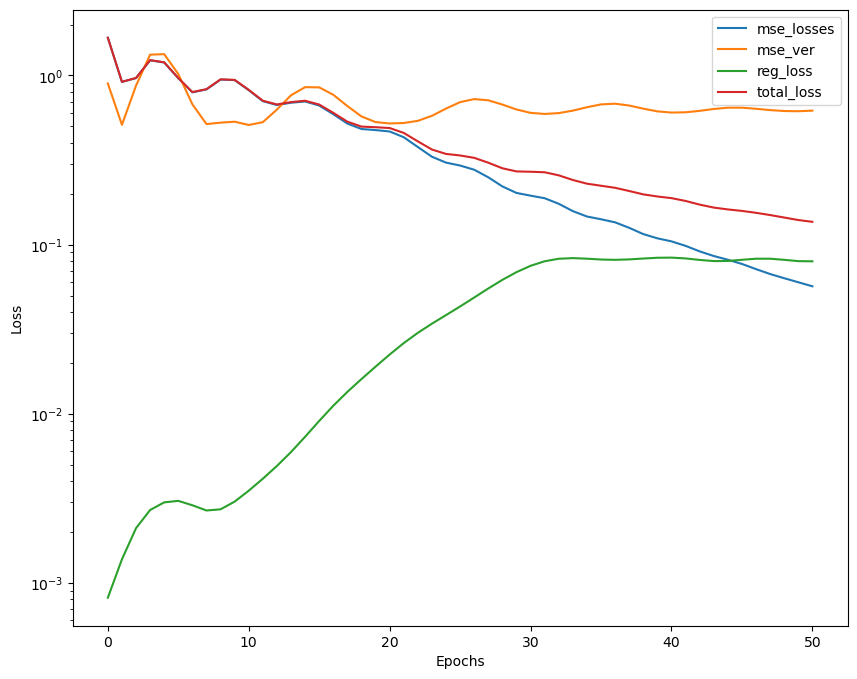

In [5]:
epoch = loss_curves['epoch']
epochs = list(range(0, (epoch)+1))
fig, ax = plt.subplots(figsize=(10,8))

for key in loss_curves:
    if not key == 'epoch':
        loss = []
        for item in loss_curves[key]:
            if isinstance(item, torch.Tensor):
                item = item.detach().cpu().numpy()
            loss.append(item)
        ax.plot(epochs, loss, label= key)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()

plt.show()

Plots

In [6]:
from Modules.Neural_Net import NetWrapper
import cmcrameri.cm as cmc

all_data = torch.load('../../data/data.pt', weights_only= True)
frame = 305
ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
grid_xy, X, Y = pre_pro.create_grid(device)
pd = torch.load('Modules/plotting_region.pt', weights_only=True).to(torch.float32)


ver_xy, ver_z = pre_pro.prepare_tensors(ver_data, device)
train_xy, train_z = pre_pro.prepare_tensors(train_data, device)
test_xy, test_z = pre_pro.prepare_tensors(test_data, device)
all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)
cen_xy, cen_z = pre_pro.prepare_tensors(cen_beam[0], device)

save_path = 'plots/'

new_net = NetWrapper(retrain_net.to('cpu'), frame = frame)

network = new_net
def plot(newtork):

    pred = network(pd).cpu()


    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
    im1 = ax1.scatter(pd[:,0].cpu(), pd[:,1].cpu(), c=pred[:,0], vmin=0, vmax=6, cmap=cmc.davos)
    scat = ax2.scatter(all_data_xy[:,0].detach().cpu(), all_data_xy[:,1].detach().cpu(), c=all_data_z[:,0].detach().cpu(), vmin=0, vmax=6, cmap=cmc.davos, s =5)

    ax1.set_aspect('equal')
    ax2.set_aspect('equal')

    ax1.set_xlim(-250, -135)
    ax1.set_ylim(-178, -146)
    ax2.set_xlim(-250, -135)
    ax2.set_ylim(-178, -146)

    ax1.set_xticklabels([])


    ax2.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
    ax1.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)    
    ax2.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)

    cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)
    cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)

    # save = f"figures/frame_{frame:03d}.png"
    # plt.savefig(save, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

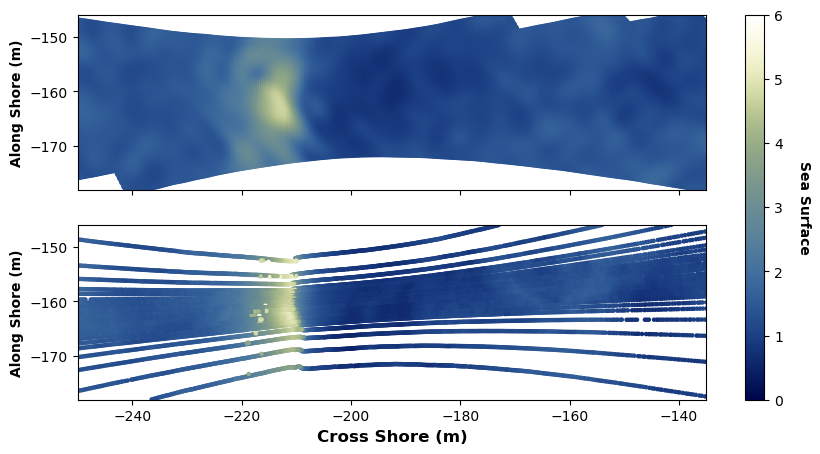

In [7]:
frame = 301

ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)

network = NetWrapper(retrain_net, frame = frame)
plot(network)